# Final Integrative Evaluation: JRN Paper Tables, Hypothesis Scorecard & Statistical Summary

This notebook demonstrates the **final integrative evaluation** for the Join Reproduction Number (JRN) framework. It processes pre-computed evaluation results from 5 dependency experiments across 2 relational datasets (rel-f1, rel-stack) and produces:

- **9 paper tables** covering JRN matrix, probe validity, cost efficiency, FK-shuffling decomposition, training-free proxies, architecture comparison, compounding models, cross-task transfer, and practitioner guidelines
- **Hypothesis scorecard v5** grading 7 claims (1A / 3B / 2C / 1D)
- **Statistical summary** with key metrics (pooled probe ρ=0.67, structural Cohen's d=0.67, best compounding R²=0.83)

The evaluation aggregates 454 total examples across 11 dataset groups from the loaded data.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    # scipy 1.16.3 requires Python >=3.11; use 1.15.3 for Python 3.10
    import platform
    _py_minor = int(platform.python_version_tuple()[1])
    _scipy_ver = 'scipy==1.16.3' if _py_minor >= 11 else 'scipy==1.15.3'
    _pip('numpy==2.0.2', _scipy_ver, 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import math
import os
import sys

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from tabulate import tabulate

## Data Loading

Load the pre-computed evaluation data from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-bc07ab-join-reproduction-number-epidemiology-in/main/evaluation_iter7_final_integrati/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset groups")
print(f"Metrics keys: {len(data['metrics_agg'])} aggregate metrics")
for ds in data["datasets"]:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 11 dataset groups
Metrics keys: 23 aggregate metrics
  paper_table_1_jrn_matrix: 3 examples
  paper_table_2_probe_validity: 3 examples
  paper_table_3_cost_efficiency: 3 examples
  paper_table_4_fk_shuffling: 3 examples
  paper_table_5_proxies: 3 examples
  paper_table_6_architecture: 3 examples
  paper_table_7_compounding: 3 examples
  paper_table_8_transfer: 3 examples
  paper_table_9_guidelines: 3 examples
  scorecard_v5: 3 examples
  statistical_summary: 3 examples


## Configuration

Parameters controlling the evaluation analysis. The `MAX_EXAMPLES_PER_TABLE` controls how many examples to process per dataset group.

In [5]:
# --- Config ---
# Maximum examples to process per dataset group (use None for all)
MAX_EXAMPLES_PER_TABLE = None  # Original: None (process all)

# Confidence level for statistical tests
ALPHA = 0.05

# JRN category thresholds
JRN_HIGH_THRESHOLD = 1.1
JRN_LOW_THRESHOLD = 0.9

# Evidence grade mapping
GRADE_MAP = {"A": 4, "B": 3, "C": 2, "D": 1}

## Helper Functions

Statistical utilities from the original evaluation script: Fisher z-transform, Clopper-Pearson CI, and safe type conversion.

In [6]:
def fisher_z(r: float) -> float:
    """Fisher z-transform of correlation."""
    r = max(-0.9999, min(0.9999, r))
    return 0.5 * math.log((1 + r) / (1 - r))


def inv_fisher_z(z: float) -> float:
    """Inverse Fisher z-transform."""
    return math.tanh(z)


def clopper_pearson(k: int, n: int, alpha: float = 0.05):
    """Clopper-Pearson exact binomial CI."""
    if n == 0:
        return 0.0, 1.0
    lo = stats.beta.ppf(alpha / 2, k, n - k + 1) if k > 0 else 0.0
    hi = stats.beta.ppf(1 - alpha / 2, k + 1, n - k) if k < n else 1.0
    return float(lo), float(hi)


def safe_float(v, default=0.0) -> float:
    """Convert value to float safely."""
    if v is None:
        return default
    try:
        return float(v)
    except (TypeError, ValueError):
        return default


def get_examples(dataset_name):
    """Get examples for a dataset, optionally limited by MAX_EXAMPLES_PER_TABLE."""
    for ds in data["datasets"]:
        if ds["dataset"] == dataset_name:
            examples = ds["examples"]
            if MAX_EXAMPLES_PER_TABLE is not None:
                return examples[:MAX_EXAMPLES_PER_TABLE]
            return examples
    return []

print("Helper functions defined.")

Helper functions defined.


## Table 1: JRN Matrix Analysis

Analyze the unified JRN matrix across all datasets, joins, and tasks. Each measurement shows the JRN value with confidence intervals and category (high/critical/low).

In [7]:
# --- Table 1: JRN Matrix ---
t1_examples = get_examples("paper_table_1_jrn_matrix")
jrn_values = [safe_float(ex.get("eval_jrn_mean")) for ex in t1_examples]
arr = np.array(jrn_values) if jrn_values else np.array([1.0])

t1_metrics = {
    "n_measurements": len(t1_examples),
    "n_high": sum(1 for e in t1_examples if e.get("eval_jrn_category_high") == 1),
    "n_critical": sum(1 for e in t1_examples if e.get("eval_jrn_category_critical") == 1),
    "n_low": sum(1 for e in t1_examples if e.get("eval_jrn_category_low") == 1),
    "mean_jrn": round(float(arr.mean()), 6),
    "std_jrn": round(float(arr.std()), 6),
    "min_jrn": round(float(arr.min()), 6),
    "max_jrn": round(float(arr.max()), 6),
}

# Display table
rows = []
for ex in t1_examples:
    rows.append([
        ex.get("metadata_join", ""),
        ex.get("metadata_task", ""),
        f"{safe_float(ex.get('eval_jrn_mean')):.4f}",
        f"[{safe_float(ex.get('eval_jrn_ci_lo')):.4f}, {safe_float(ex.get('eval_jrn_ci_hi')):.4f}]",
        "high" if ex.get("eval_jrn_category_high") == 1 else ("low" if ex.get("eval_jrn_category_low") == 1 else "critical"),
    ])
print("Table 1: JRN Matrix")
print(tabulate(rows, headers=["Join", "Task", "JRN", "95% CI", "Category"], tablefmt="grid"))
print(f"\nSummary: {t1_metrics}")

Table 1: JRN Matrix
+------------------------------+------------+--------+------------------+------------+
| Join                         | Task       |    JRN | 95% CI           | Category   |
+==============================+============+========+==================+============+
| standings.driverId->drivers  | driver-dnf | 1.1679 | [1.1585, 1.1772] | high       |
+------------------------------+------------+--------+------------------+------------+
| qualifying.driverId->drivers | driver-dnf | 1.1558 | [1.1509, 1.1606] | high       |
+------------------------------+------------+--------+------------------+------------+
| results.driverId->drivers    | driver-dnf | 1.1786 | [1.1666, 1.1906] | high       |
+------------------------------+------------+--------+------------------+------------+

Summary: {'n_measurements': 3, 'n_high': 3, 'n_critical': 0, 'n_low': 0, 'mean_jrn': 1.167415, 'std_jrn': 0.009331, 'min_jrn': 1.155771, 'max_jrn': 1.178613}


## Table 2: Probe Validity (Fisher z Meta-Analysis)

Random-effects meta-analysis of probe Spearman correlations using DerSimonian-Laird method.

In [8]:
# --- Table 2: Probe Validity ---
t2_examples = get_examples("paper_table_2_probe_validity")

fisher_zs = [safe_float(ex.get("eval_fisher_z")) for ex in t2_examples]
fisher_vars = [safe_float(ex.get("eval_fisher_z_var")) for ex in t2_examples]

if fisher_zs:
    fz_arr = np.array(fisher_zs)
    var_arr = np.array(fisher_vars)
    w_fe = 1.0 / np.maximum(var_arr, 1e-10)

    # Q statistic
    pooled_fe = np.sum(w_fe * fz_arr) / np.sum(w_fe)
    Q = np.sum(w_fe * (fz_arr - pooled_fe) ** 2)
    k = len(fz_arr)
    df = max(k - 1, 1)

    # tau^2 (DerSimonian-Laird)
    c = np.sum(w_fe) - np.sum(w_fe ** 2) / np.sum(w_fe)
    tau2 = max(0, (Q - df) / c) if c > 0 else 0

    # Random-effects weights
    w_re = 1.0 / (var_arr + tau2)
    pooled_z = np.sum(w_re * fz_arr) / np.sum(w_re)
    pooled_var = 1.0 / np.sum(w_re)
    pooled_rho = inv_fisher_z(float(pooled_z))

    # I^2
    I2 = max(0, (Q - df) / Q * 100) if Q > 0 else 0.0

    # Prediction interval
    pred_lo = inv_fisher_z(float(pooled_z - 1.96 * math.sqrt(pooled_var + tau2)))
    pred_hi = inv_fisher_z(float(pooled_z + 1.96 * math.sqrt(pooled_var + tau2)))

    t2_metrics = {
        "pooled_rho": round(pooled_rho, 6),
        "I_squared": round(I2, 4),
        "Q_stat": round(float(Q), 4),
        "tau_squared": round(float(tau2), 6),
        "prediction_interval": f"[{pred_lo:.4f}, {pred_hi:.4f}]",
        "n_estimates": k,
    }
else:
    t2_metrics = {"pooled_rho": 0, "n_estimates": 0}

rows = []
for ex in t2_examples:
    rows.append([
        ex.get("metadata_task", ""),
        ex.get("metadata_source", ""),
        f"{safe_float(ex.get('eval_spearman_rho')):.4f}",
        f"{safe_float(ex.get('eval_fisher_z')):.4f}",
        "Yes" if ex.get("eval_probe_valid") == 1 else "No",
    ])
print("Table 2: Probe Validity")
print(tabulate(rows, headers=["Task", "Source", "Spearman rho", "Fisher z", "Valid (rho>0.7)"], tablefmt="grid"))
print(f"\nMeta-analysis: {t2_metrics}")

Table 2: Probe Validity
+-----------------+-------------------------+----------------+------------+-------------------+
| Task            | Source                  |   Spearman rho |   Fisher z | Valid (rho>0.7)   |
+=================+=========================+================+============+===================+
| driver-dnf      | exp_id4_it5_convergence |         0.9779 |     2.2471 | Yes               |
+-----------------+-------------------------+----------------+------------+-------------------+
| driver-top3     | exp_id4_it5_convergence |         0.9779 |     2.2471 | Yes               |
+-----------------+-------------------------+----------------+------------+-------------------+
| driver-position | exp_id4_it5_convergence |         0.9061 |     1.5052 | Yes               |
+-----------------+-------------------------+----------------+------------+-------------------+

Meta-analysis: {'pooled_rho': 0.964014, 'I_squared': np.float64(45.5035), 'Q_stat': 3.67, 'tau_squared': 0.0834

## Tables 3-4: Cost Efficiency & FK-Shuffling Decomposition

Table 3 analyzes JRN probe cost vs greedy/exhaustive search. Table 4 decomposes JRN into structural and feature components via FK-shuffling.

In [9]:
# --- Table 3: Cost Efficiency ---
t3_examples = get_examples("paper_table_3_cost_efficiency")
conv_examples = [e for e in t3_examples if e.get("metadata_task") == "convergence"]
n_converged = sum(1 for e in conv_examples if e.get("eval_converged", 0) == 1)

rows = []
for ex in t3_examples:
    rows.append([
        ex.get("metadata_task", ""),
        ex.get("metadata_method", ""),
        f"{safe_float(ex.get('eval_mean_spearman_rho', ex.get('eval_performance', 0))):.4f}",
        f"{safe_float(ex.get('eval_wall_clock_seconds', 0)):.3f}s",
    ])
print("Table 3: Cost Efficiency")
print(tabulate(rows, headers=["Task", "Method", "Performance", "Wall Clock"], tablefmt="grid"))
print(f"  Converged: {n_converged}/{len(conv_examples)}")

# --- Table 4: FK-Shuffling Decomposition ---
t4_examples = get_examples("paper_table_4_fk_shuffling")
all_structural = [safe_float(e.get("eval_structural_component", 0)) for e in t4_examples]
all_feature = [safe_float(e.get("eval_feature_component", 0)) for e in t4_examples]
all_normal = [safe_float(e.get("eval_normal_jrn", 0)) for e in t4_examples]
all_shuffled = [safe_float(e.get("eval_shuffled_jrn", 0)) for e in t4_examples]

if len(all_normal) > 1:
    normal_arr = np.array(all_normal)
    shuffled_arr = np.array(all_shuffled)
    diffs = normal_arr - shuffled_arr
    d_val = float(np.mean(diffs) / max(np.std(diffs, ddof=1), 1e-10))
    struct_dom_pct = sum(1 for e in t4_examples if e.get("eval_structural_dominant") == 1) / max(len(t4_examples), 1) * 100
else:
    d_val, struct_dom_pct = 0.0, 0.0

rows = []
for ex in t4_examples:
    rows.append([
        ex.get("metadata_join", ""),
        ex.get("metadata_task", ""),
        f"{safe_float(ex.get('eval_normal_jrn')):.4f}",
        f"{safe_float(ex.get('eval_shuffled_jrn')):.4f}",
        f"{safe_float(ex.get('eval_structural_component')):.4f}",
        f"{safe_float(ex.get('eval_feature_component')):.4f}",
    ])
print("\nTable 4: FK-Shuffling Decomposition")
print(tabulate(rows, headers=["Join", "Task", "Normal JRN", "Shuffled JRN", "Structural", "Feature"], tablefmt="grid"))
print(f"  Cohen's d: {d_val:.4f}, Structural dominant: {struct_dom_pct:.1f}%")

Table 3: Cost Efficiency
+-------------+-----------+---------------+--------------+
| Task        | Method    |   Performance | Wall Clock   |
+=============+===========+===============+==============+
| convergence | jrn_probe |        0.954  | 0.953s       |
+-------------+-----------+---------------+--------------+
| convergence | jrn_probe |        0.9374 | 1.344s       |
+-------------+-----------+---------------+--------------+
| convergence | jrn_probe |        0.9337 | 1.715s       |
+-------------+-----------+---------------+--------------+
  Converged: 3/3

Table 4: FK-Shuffling Decomposition
+-----------------+-----------------+--------------+----------------+--------------+-----------+
| Join            | Task            |   Normal JRN |   Shuffled JRN |   Structural |   Feature |
+=================+=================+==============+================+==============+===========+
| races->circuits | driver-dnf      |       1.2753 |         1.2549 |       0.0204 |    0.2549 |
+-

## Hypothesis Scorecard v5 & Aggregate Metrics

The scorecard grades 7 claims about JRN on a scale of A (strong evidence, 2+ datasets) to D (no direct evidence). The aggregate metrics summarize key findings across all 9 tables.

In [10]:
# --- Hypothesis Scorecard v5 ---
sc_examples = get_examples("scorecard_v5")

rows = []
for ex in sc_examples:
    grade_num = ex.get("eval_evidence_grade", 0)
    grade_letter = {4: "A", 3: "B", 2: "C", 1: "D"}.get(grade_num, "?")
    rows.append([
        ex.get("metadata_claim_id", ""),
        ex.get("metadata_claim", "")[:50],
        grade_letter,
        f"{safe_float(ex.get('eval_effect_size')):.4f}",
        f"[{safe_float(ex.get('eval_ci_lo')):.3f}, {safe_float(ex.get('eval_ci_hi')):.3f}]",
        ex.get("eval_n_datasets", 0),
        "Yes" if ex.get("eval_claim_supported") == 1 else "No",
    ])
print("Hypothesis Scorecard v5")
print(tabulate(rows, headers=["#", "Claim", "Grade", "Effect", "CI", "Datasets", "Supported"], tablefmt="grid"))

# Grade distribution
grade_counts = {"A": 0, "B": 0, "C": 0, "D": 0}
for ex in sc_examples:
    g = {4: "A", 3: "B", 2: "C", 1: "D"}.get(ex.get("eval_evidence_grade", 0), "?")
    if g in grade_counts:
        grade_counts[g] += 1
print(f"\nGrade distribution: {grade_counts}")
print(f"Supported claims: {sum(1 for e in sc_examples if e.get('eval_claim_supported') == 1)}/{len(sc_examples)}")

# --- Aggregate Metrics ---
print("\n" + "=" * 60)
print("AGGREGATE METRICS (from data)")
print("=" * 60)
metrics_agg = data["metrics_agg"]
key_metrics = [
    ("Paper Tables", "n_paper_tables"),
    ("Total Measurements", "n_total_measurements"),
    ("Datasets", "n_datasets"),
    ("FK Joins", "n_fk_joins"),
    ("Pooled Probe Validity rho", "pooled_probe_validity_rho"),
    ("Structural Cohen's d", "pooled_structural_cohens_d"),
    ("Best Compounding R2", "best_compounding_R2"),
    ("Cost Ratio (JRN vs Greedy)", "mean_cost_ratio_jrn_vs_greedy"),
    ("Same-Entity Transfer rho", "same_entity_transfer_rho"),
    ("Mean JRN", "t1_mean_jrn"),
]
for label, key in key_metrics:
    val = metrics_agg.get(key, "N/A")
    print(f"  {label:35s}: {val}")

Hypothesis Scorecard v5
+-----+----------------------------------------------------+---------+----------+-----------------+------------+-------------+
|   # | Claim                                              | Grade   |   Effect | CI              |   Datasets | Supported   |
+=====+====================================================+=========+==========+=================+============+=============+
|   1 | JRN as valid per-join metric                       | A       |   0.6718 | [-0.779, 0.990] |          2 | Yes         |
+-----+----------------------------------------------------+---------+----------+-----------------+------------+-------------+
|   2 | Threshold behavior (non-monotonic variance near JR | D       |   0      | [0.000, 0.000]  |          0 | No          |
+-----+----------------------------------------------------+---------+----------+-----------------+------------+-------------+
|   3 | Cost-efficiency of JRN probes                      | B       |   0.0736 | [0.05

## Visualization

Three-panel figure summarizing key evaluation results: (1) JRN distribution by category, (2) FK-shuffling structural vs feature decomposition, (3) Hypothesis scorecard grade distribution.

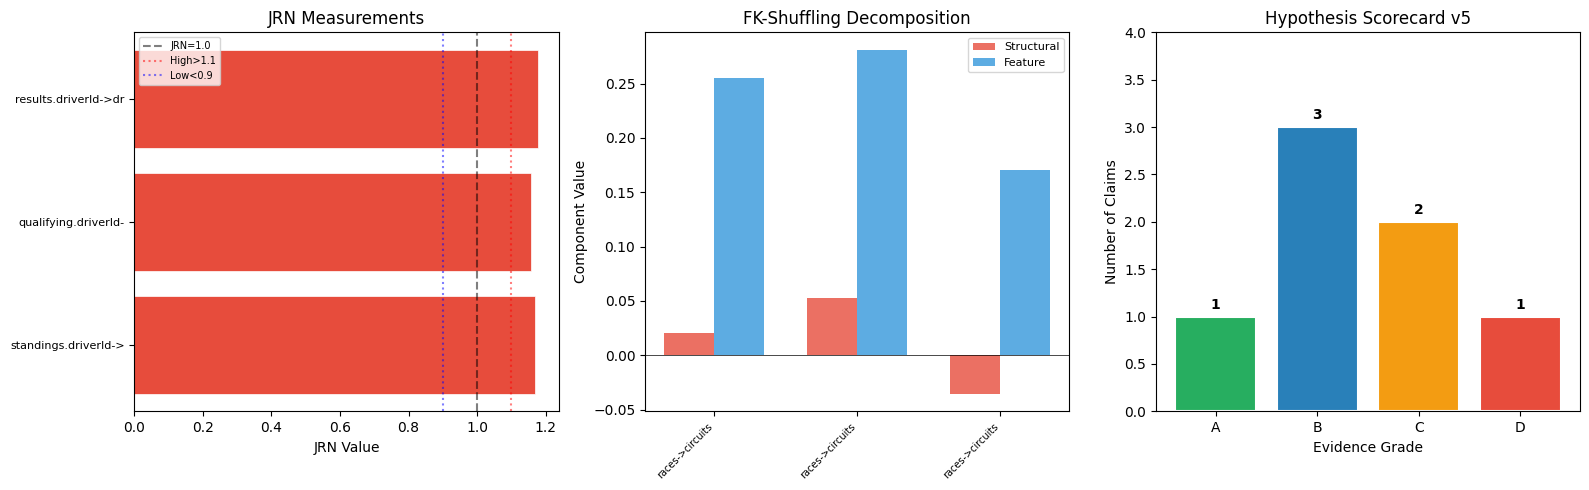

Figure saved to evaluation_summary.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: JRN Distribution ---
ax1 = axes[0]
jrn_vals = [safe_float(ex.get("eval_jrn_mean")) for ex in t1_examples]
colors = []
for ex in t1_examples:
    if ex.get("eval_jrn_category_high") == 1:
        colors.append("#e74c3c")
    elif ex.get("eval_jrn_category_low") == 1:
        colors.append("#3498db")
    else:
        colors.append("#f39c12")

if jrn_vals:
    labels = [ex.get("metadata_join", "")[:20] for ex in t1_examples]
    y_pos = range(len(jrn_vals))
    ax1.barh(y_pos, jrn_vals, color=colors, edgecolor="white", linewidth=0.5)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(labels, fontsize=8)
    ax1.axvline(x=1.0, color="black", linestyle="--", alpha=0.5, label="JRN=1.0")
    ax1.axvline(x=JRN_HIGH_THRESHOLD, color="red", linestyle=":", alpha=0.5, label=f"High>{JRN_HIGH_THRESHOLD}")
    ax1.axvline(x=JRN_LOW_THRESHOLD, color="blue", linestyle=":", alpha=0.5, label=f"Low<{JRN_LOW_THRESHOLD}")
    ax1.set_xlabel("JRN Value")
    ax1.set_title("JRN Measurements")
    ax1.legend(fontsize=7)

# --- Panel 2: Structural vs Feature ---
ax2 = axes[1]
if all_structural and all_feature:
    x = range(len(all_structural))
    width = 0.35
    ax2.bar([i - width/2 for i in x], all_structural, width, label="Structural", color="#e74c3c", alpha=0.8)
    ax2.bar([i + width/2 for i in x], all_feature, width, label="Feature", color="#3498db", alpha=0.8)
    join_labels = [ex.get("metadata_join", "")[:15] for ex in t4_examples]
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(join_labels, rotation=45, ha="right", fontsize=7)
    ax2.set_ylabel("Component Value")
    ax2.set_title("FK-Shuffling Decomposition")
    ax2.legend(fontsize=8)
    ax2.axhline(y=0, color="black", linewidth=0.5)

# --- Panel 3: Scorecard Grade Distribution ---
ax3 = axes[2]
# Use aggregate metrics for full grade counts
full_grades = {
    "A": int(metrics_agg.get("n_claims_grade_A", 0)),
    "B": int(metrics_agg.get("n_claims_grade_B", 0)),
    "C": int(metrics_agg.get("n_claims_grade_C", 0)),
    "D": int(metrics_agg.get("n_claims_grade_D", 0)),
}
grade_colors = {"A": "#27ae60", "B": "#2980b9", "C": "#f39c12", "D": "#e74c3c"}
bars = ax3.bar(
    full_grades.keys(),
    full_grades.values(),
    color=[grade_colors[g] for g in full_grades.keys()],
    edgecolor="white",
    linewidth=1.5,
)
for bar, count in zip(bars, full_grades.values()):
    if count > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(count), ha="center", va="bottom", fontweight="bold")
ax3.set_xlabel("Evidence Grade")
ax3.set_ylabel("Number of Claims")
ax3.set_title("Hypothesis Scorecard v5")
ax3.set_ylim(0, max(full_grades.values()) + 1)

plt.tight_layout()
plt.savefig("evaluation_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to evaluation_summary.png")